**TAREA 1**: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

Total de filas destacadas: 7 
Filas destacadas: [  6  12  15  20  21  88 100]


(0.0, 512.0)

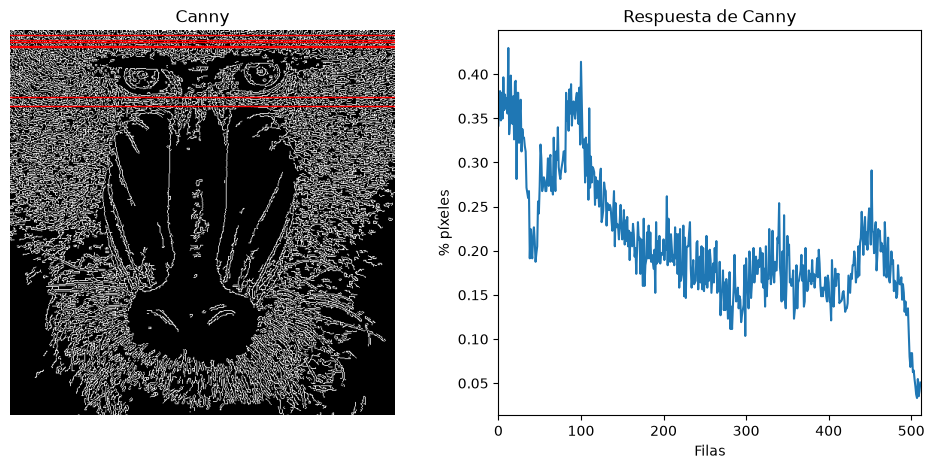

In [12]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('mandril.jpg')
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#Obtiene contornos con el operador de Canny
#Parámetros: imagen de entrada, umbral inferior, umbral superior
canny = cv2.Canny(gris, 100, 200) #prueba a jugar con umbrales (entre 0 y 255)

#El contenido de la imagen resultado de Canny, son valores 0 o 255, lo compruebas al descomentar
#print(canny)
#Cuenta el número de píxeles blancos (255) por columna
#Suma los valores de los pixeles por columna
fil_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Normaliza en base al número de filas, primer valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el número de píxeles blancos por columna
fils = fil_counts[:,0] / (255 * canny.shape[1])

umbral = max(fil_counts[:,0])*0.9
noted_fils = np.where(fil_counts[:,0] > (umbral))[0]


print(f'Total de filas destacadas: {len(noted_fils)} \nFilas destacadas: {noted_fils}')
#Muestra dicha cuenta gráficamente
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap="gray") 

for i in noted_fils:
    plt.axhline(y=i, color="red", linewidth=1)

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(fils)
#Rango en x definido por las filas
plt.xlim([0, canny.shape[0]])

**TAREA 2**: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?


---------------------------------- RESULTADOS SOBEL --------------------------------------------
Total de filas destacadas: 25 
Filas destacadas: [  1   2   3   4   5   6   7   8  11  12  19  20  24  51  52  80  81  82
  83  84  85  86  87  96 100]
Total de columnas destacadas: 12 
Columnas destacadas: [ 99 103 104 105 123 124 125 126 127 128 287 288]
---------------------------------- RESULTADOS CANNY --------------------------------------------
Total de filas destacadas: 7 
Filas destacadas: [  6  12  15  20  21  88 100]
Total de columnas destacadas: 19 
Columnas destacadas: [ 67  86  92  96  99 100 103 104 105 112 115 119 123 379 380 383 392 396
 403]


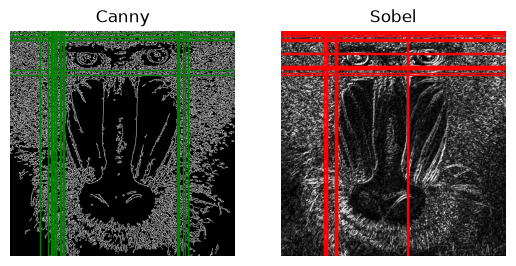

In [10]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('mandril.jpg')
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

###------------------------ SOBEL ----------------------------------------------------------------------
# Gaussiana para suavizar la imagen original, eliminando altas frecuencias
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

#
#Calcula en ambas direcciones (horizontal y vertical)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
#Combina ambos resultados
sobel = cv2.add(sobelx, sobely)
cvt_sobel = cv2.convertScaleAbs(sobel)

sobel_col_counts = cv2.reduce(cvt_sobel, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
sobel_fil_counts = cv2.reduce(cvt_sobel, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

sobel_col_umbral = max(sobel_col_counts[0]) * 0.9
sobel_fil_umbral = max(sobel_fil_counts[:,0]) * 0.9

sobel_noted_col = np.where(sobel_col_counts[0] > sobel_col_umbral)[0]
sobel_noted_fil = np.where(sobel_fil_counts[:,0] > sobel_fil_umbral)[0]

print('---------------------------------- RESULTADOS SOBEL --------------------------------------------')
print(f'Total de filas destacadas: {len(sobel_noted_fil)} \nFilas destacadas: {sobel_noted_fil}')
print(f'Total de columnas destacadas: {len(sobel_noted_col)} \nColumnas destacadas: {sobel_noted_col}')


#-------------------------- CANNY ----------------------------------------------------------------------

canny = cv2.Canny(gris, 100, 200) #prueba a jugar con umbrales (entre 0 y 255)

canny_fil_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
canny_col_counts = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

canny_fil_umbral = max(canny_fil_counts[:,0]) * 0.9
canny_col_umbral = max(canny_col_counts[0]) * 0.9

canny_noted_fil = np.where(canny_fil_counts[:,0] > canny_fil_umbral)[0]
canny_noted_col = np.where(canny_col_counts[0] > canny_col_umbral)[0]

#Normaliza en base al número de filas, primer valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el número de píxeles blancos por columna
#fils = canny_fil_counts[:,0] / (255 * canny.shape[1])  ESTE CALCULO SE USA EN CASO DE MOSTRAR GRAFICA
print('---------------------------------- RESULTADOS CANNY --------------------------------------------')
print(f'Total de filas destacadas: {len(canny_noted_fil)} \nFilas destacadas: {canny_noted_fil}')
print(f'Total de columnas destacadas: {len(canny_noted_col)} \nColumnas destacadas: {canny_noted_col}')

#Muestra ambos resultados
plt.figure()

plt.subplot(1, 2, 1)
plt.axis("off")

for i in canny_noted_fil:
    plt.axhline(y=i, color="green", linewidth=1)

for j in canny_noted_col:
    plt.axvline(x=j, color="green", linewidth=1)

plt.title('Canny')
#Para visualizar convierte a escala manejable en una imagen de grises
plt.imshow(canny, cmap='gray') 

plt.subplot(1, 2, 2)
plt.axis("off")

for i in sobel_noted_fil:
    plt.axhline(y=i, color="red", linewidth=1)

for j in sobel_noted_col:
    plt.axvline(x=j, color="red", linewidth=1)

plt.title('Sobel')
#Para visualizar convierte a escala manejable en una imagen de grises
plt.imshow(cvt_sobel, cmap='gray') 
#plt.imshow(sobel, cmap='gray') #Prueba sin convertir escala
plt.show()

**TAREA 3**: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.